# Анализ результатов Entity Resolution

Визуализация метрик после обучения `03_train_er_without_sm.py --all`.

Два уровня оценки:
- **In-domain**: test-сплит обучающих датасетов (модель видела домен при обучении)
- **Cross-domain**: все пары hold-out датасетов (модель НЕ видела ни одной строки)

Основные метрики (threshold-independent):
- **ROC-AUC** — площадь под ROC-кривой
- **Average Precision** — площадь под PR-кривой

Загружаем из `output/er_results_multidataset.json`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("../output")
RESULTS_PATH = OUTPUT_DIR / "er_results_multidataset.json"

if RESULTS_PATH.exists():
    with open(RESULTS_PATH, encoding="utf-8") as f:
        results = json.load(f)
    print(f"Режим: {results['mode']}")
    print(f"Train датасетов: {len(results['train_datasets'])}")
    print(f"Holdout датасетов: {len(results['holdout_datasets'])}")
    print(f"Train triplets: {results['total_train_triplets']:,}")
    print(f"Val triplets: {results['total_val_triplets']:,}")
    if results.get("failed"):
        print(f"Failed: {results['failed']}")
else:
    raise FileNotFoundError(
        f"{RESULTS_PATH} не найден — сначала запустите:\n"
        "  python -m experiments.03_train_er_without_sm --all"
    )

Режим: multidataset_holdout
Train датасетов: 19
Holdout датасетов: 5
Train triplets: 6,220
Val triplets: 1,215


## 1. Кривые обучения (Train / Val Loss)

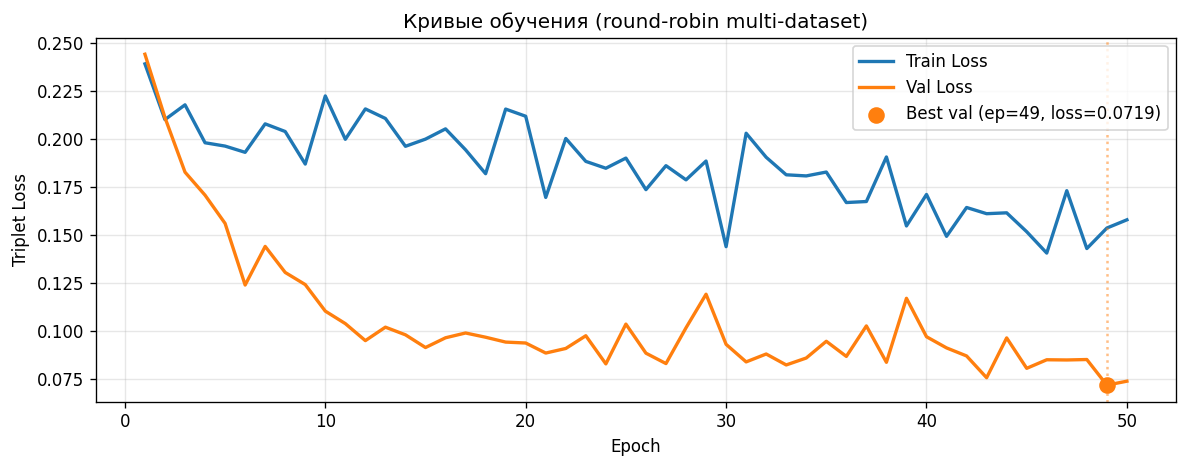

Final train loss: 0.1580
Best val loss: 0.0719 (epoch 49)


In [2]:
history = results["history"]

fig, ax = plt.subplots(figsize=(10, 4))
epochs = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
if history.get("val_loss"):
    ax.plot(epochs, history["val_loss"], label="Val Loss", linewidth=2)
    best_ep = int(np.argmin(history["val_loss"])) + 1
    best_val = min(history["val_loss"])
    ax.axvline(best_ep, color="C1", ls=":", alpha=0.5)
    ax.scatter([best_ep], [best_val], color="C1", s=80, zorder=5,
               label=f"Best val (ep={best_ep}, loss={best_val:.4f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Triplet Loss")
ax.set_title("Кривые обучения (round-robin multi-dataset)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
if history.get("val_loss"):
    print(f"Best val loss: {best_val:.4f} (epoch {best_ep})")

## 2. In-domain результаты (обучающие датасеты)

In [3]:
df_in = pd.DataFrame(results["in_domain_results"])
metric_cols = ["roc_auc", "avg_precision"]
show_cols = ["name", "domain"] + metric_cols + ["n_pos", "n_neg"]
show_cols = [c for c in show_cols if c in df_in.columns]

display(df_in[show_cols].style
    .set_caption(f"In-domain: метрики на test-сплите ({len(df_in)} обучающих датасетов)")
    .background_gradient(subset=[c for c in metric_cols if c in df_in.columns], cmap="RdYlGn", vmin=0, vmax=1)
    .format({c: "{:.4f}" for c in metric_cols if c in df_in.columns})
)

for m in metric_cols:
    if m in df_in.columns:
        vals = df_in[m].dropna()
        print(f"  {m:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")

,name,domain,roc_auc,avg_precision,n_pos,n_neg
0,baby_products,baby products,0.3875,0.2156,14.000000,40.000000
1,beer,beer,0.8370,0.7035,13.000000,76.000000
2,bikes,bikes,0.6087,0.4049,22.000000,64.000000
3,books1,books,0.7409,0.8271,46.000000,25.000000
4,books3,books,0.6332,0.8799,68.000000,17.000000
5,books4,books,0.8443,0.7331,20.000000,61.000000
6,books5,books,0.8209,0.6390,9.000000,67.000000
7,cosmetics,cosmetics,nan,nan,nan,nan
8,ebooks1,ebooks,0.9094,0.8460,27.000000,47.000000
9,ebooks2,ebooks,nan,nan,nan,nan


  roc_auc        : 0.7778 ± 0.1658
  avg_precision  : 0.7039 ± 0.2234


## 3. Cross-domain результаты (hold-out датасеты)

In [4]:
if results["cross_domain_results"]:
    df_cross = pd.DataFrame(results["cross_domain_results"])
    show_cols_cross = [c for c in show_cols if c in df_cross.columns]

    display(df_cross[show_cols_cross].style
        .set_caption(f"Cross-domain: метрики на {len(df_cross)} hold-out датасетах (модель их НЕ видела)")
        .background_gradient(subset=[c for c in metric_cols if c in df_cross.columns], cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.4f}" for c in metric_cols if c in df_cross.columns})
    )

    for m in metric_cols:
        if m in df_cross.columns:
            vals = df_cross[m].dropna()
            print(f"  {m:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")
else:
    print("Нет cross-domain результатов (запуск с --no-holdout?)")
    df_cross = pd.DataFrame()

,name,domain,roc_auc,avg_precision,n_pos,n_neg
0,anime,anime,0.9020,0.8875,37,40
1,books2,books,0.5852,0.3028,17,58
2,citations,bibliography,0.5987,0.2747,15,53
3,electronics,electronics,0.7799,0.3751,14,61
4,restaurants3,restaurants,0.6741,0.5194,16,56


  roc_auc        : 0.7080 ± 0.1332
  avg_precision  : 0.4719 ± 0.2509


## 4. Сравнение In-domain vs Cross-domain

/tmp/ipykernel_3283307/1147089211.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],
/tmp/ipykernel_3283307/1147089211.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],


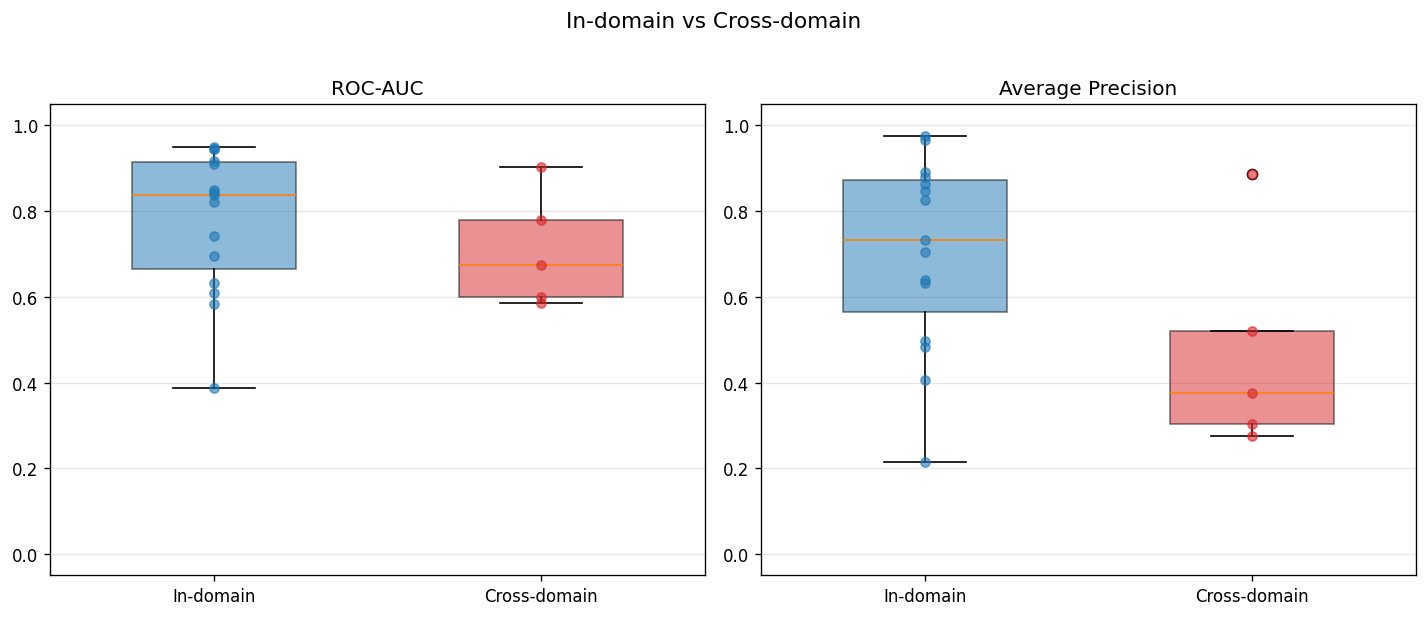

,Metric,In-domain (mean),Cross-domain (mean),Drop
0,ROC-AUC,0.7778,0.7080,0.0699
1,Avg Precision,0.7039,0.4719,0.2320


In [5]:
if not df_cross.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, metric, title in zip(axes, ["roc_auc", "avg_precision"],
                                       ["ROC-AUC", "Average Precision"]):
        in_vals = df_in[metric].dropna()
        cross_vals = df_cross[metric].dropna()

        bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],
                        patch_artist=True, widths=0.5)
        bp["boxes"][0].set_facecolor("C0")
        bp["boxes"][0].set_alpha(0.5)
        bp["boxes"][1].set_facecolor("C3")
        bp["boxes"][1].set_alpha(0.5)

        ax.scatter(np.ones(len(in_vals)), in_vals, alpha=0.6, s=30, zorder=5, color="C0")
        ax.scatter(np.ones(len(cross_vals)) * 2, cross_vals, alpha=0.6, s=30, zorder=5, color="C3")

        ax.set_title(title)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle("In-domain vs Cross-domain", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    comparison = pd.DataFrame({
        "Metric": ["ROC-AUC", "Avg Precision"],
        "In-domain (mean)": [df_in["roc_auc"].mean(), df_in["avg_precision"].mean()],
        "Cross-domain (mean)": [df_cross["roc_auc"].mean(), df_cross["avg_precision"].mean()],
    })
    comparison["Drop"] = comparison["In-domain (mean)"] - comparison["Cross-domain (mean)"]
    display(comparison.style.format("{:.4f}", subset=["In-domain (mean)", "Cross-domain (mean)", "Drop"])
            .set_caption("Падение метрик на unseen доменах"))
else:
    print("Нет cross-domain результатов для сравнения.")

## 5. ROC-AUC по каждому датасету (bar chart)

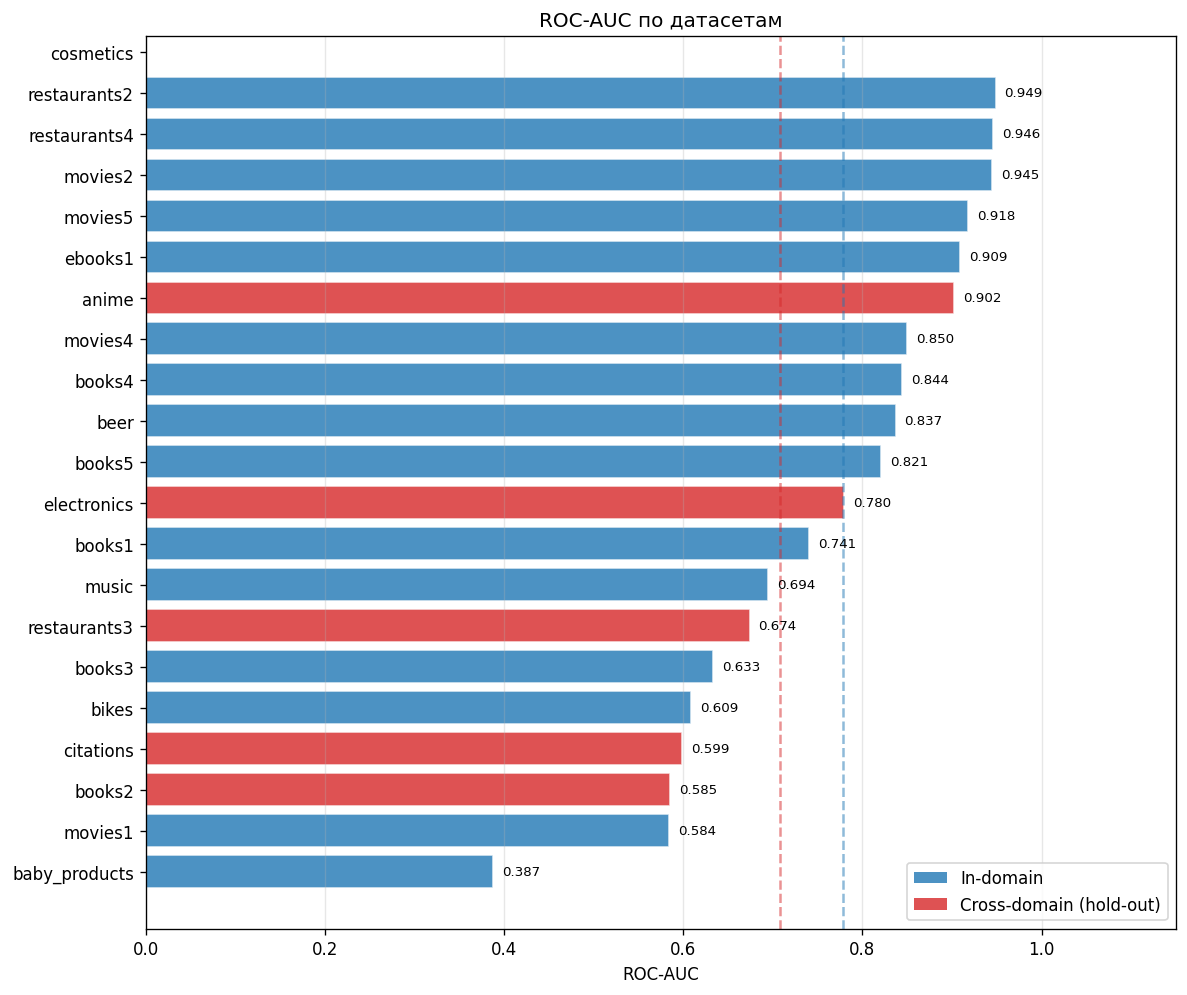

In [6]:
df_all = pd.concat([df_in, df_cross], ignore_index=True) if not df_cross.empty else df_in.copy()
df_all = df_all.sort_values("roc_auc", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_all) * 0.35)))

colors = ["C3" if et == "cross-domain" else "C0" for et in df_all["eval_type"]]
bars = ax.barh(df_all["name"], df_all["roc_auc"], color=colors, alpha=0.8, edgecolor="white")

for bar, val in zip(bars, df_all["roc_auc"]):
    if pd.notna(val):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

ax.set_xlabel("ROC-AUC")
ax.set_xlim(0, 1.15)
ax.set_title("ROC-AUC по датасетам")
ax.axvline(df_in["roc_auc"].mean(), color="C0", ls="--", alpha=0.5,
           label=f"In-domain mean={df_in['roc_auc'].mean():.3f}")
if not df_cross.empty:
    ax.axvline(df_cross["roc_auc"].mean(), color="C3", ls="--", alpha=0.5,
               label=f"Cross-domain mean={df_cross['roc_auc'].mean():.3f}")

handles = [Patch(facecolor="C0", alpha=0.8, label="In-domain"),
           Patch(facecolor="C3", alpha=0.8, label="Cross-domain (hold-out)")]
ax.legend(handles=handles, loc="lower right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 6. Метрики по доменам

In [7]:
domain_agg = (df_all.groupby(["domain", "eval_type"])
              .agg(roc_auc=("roc_auc", "mean"),
                   avg_precision=("avg_precision", "mean"), n_datasets=("name", "count"))
              .sort_values("roc_auc", ascending=False))

display(domain_agg.style
    .set_caption("Средние метрики по доменам")
    .format({"roc_auc": "{:.4f}", "avg_precision": "{:.4f}"})
    .background_gradient(subset=["roc_auc"], cmap="RdYlGn", vmin=0, vmax=1)
)

,,roc_auc,avg_precision,n_datasets
domain,eval_type,,,
restaurants,in-domain,0.9474,0.8778,3
ebooks,in-domain,0.9094,0.8460,2
anime,cross-domain,0.9020,0.8875,1
beer,in-domain,0.8370,0.7035,1
movies,in-domain,0.8242,0.7677,5
electronics,cross-domain,0.7799,0.3751,1
books,in-domain,0.7598,0.7698,4
music,in-domain,0.6943,0.4829,1
restaurants,cross-domain,0.6741,0.5194,1


## 7. Итоговая сводка

In [8]:
print("=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)
print(f"Модель: output/er_model_multidataset.pt")
print(f"Эпох: {len(history['train_loss'])}")
print(f"Train датасетов: {len(results['train_datasets'])}  {results['train_datasets']}")
print(f"Holdout датасетов: {len(results['holdout_datasets'])}  {results['holdout_datasets']}")
print()

def _print_summary(label, df):
    print(f"--- {label} ---")
    for metric in ["roc_auc", "avg_precision"]:
        if metric in df.columns:
            vals = df[metric].dropna()
            print(f"  {metric:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}  "
                  f"(min={vals.min():.4f}, max={vals.max():.4f})")

_print_summary("IN-DOMAIN (test split)", df_in)
if not df_cross.empty:
    print()
    _print_summary("CROSS-DOMAIN (hold-out, все пары)", df_cross)

print()
print("Худшие датасеты (ROC-AUC < 0.6):")
worst = df_all[df_all["roc_auc"] < 0.6][["name", "eval_type", "roc_auc", "avg_precision"]]
if len(worst) > 0:
    for _, row in worst.iterrows():
        print(f"  {row['name']:20s} ({row['eval_type']}) "
              f"\u2014 AUC={row['roc_auc']:.4f}, AP={row['avg_precision']:.4f}")
else:
    print("  Нет (все ROC-AUC >= 0.6)")

ИТОГОВАЯ СВОДКА
Модель: output/er_model_multidataset.pt
Эпох: 50
Train датасетов: 19  ['baby_products', 'beer', 'bikes', 'books1', 'books3', 'books4', 'books5', 'cosmetics', 'ebooks1', 'ebooks2', 'movies1', 'movies2', 'movies3', 'movies4', 'movies5', 'music', 'restaurants1', 'restaurants2', 'restaurants4']
Holdout датасетов: 5  ['anime', 'books2', 'citations', 'electronics', 'restaurants3']

--- IN-DOMAIN (test split) ---
  roc_auc        : 0.7778 ± 0.1658  (min=0.3875, max=0.9487)
  avg_precision  : 0.7039 ± 0.2234  (min=0.2156, max=0.9743)

--- CROSS-DOMAIN (hold-out, все пары) ---
  roc_auc        : 0.7080 ± 0.1332  (min=0.5852, max=0.9020)
  avg_precision  : 0.4719 ± 0.2509  (min=0.2747, max=0.8875)

Худшие датасеты (ROC-AUC < 0.6):
  baby_products        (in-domain) — AUC=0.3875, AP=0.2156
  movies1              (in-domain) — AUC=0.5842, AP=0.4972
  books2               (cross-domain) — AUC=0.5852, AP=0.3028
  citations            (cross-domain) — AUC=0.5987, AP=0.2747
